In [1]:
from SCFT_functions import *
from DNA_input import *

import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange

Using cupy


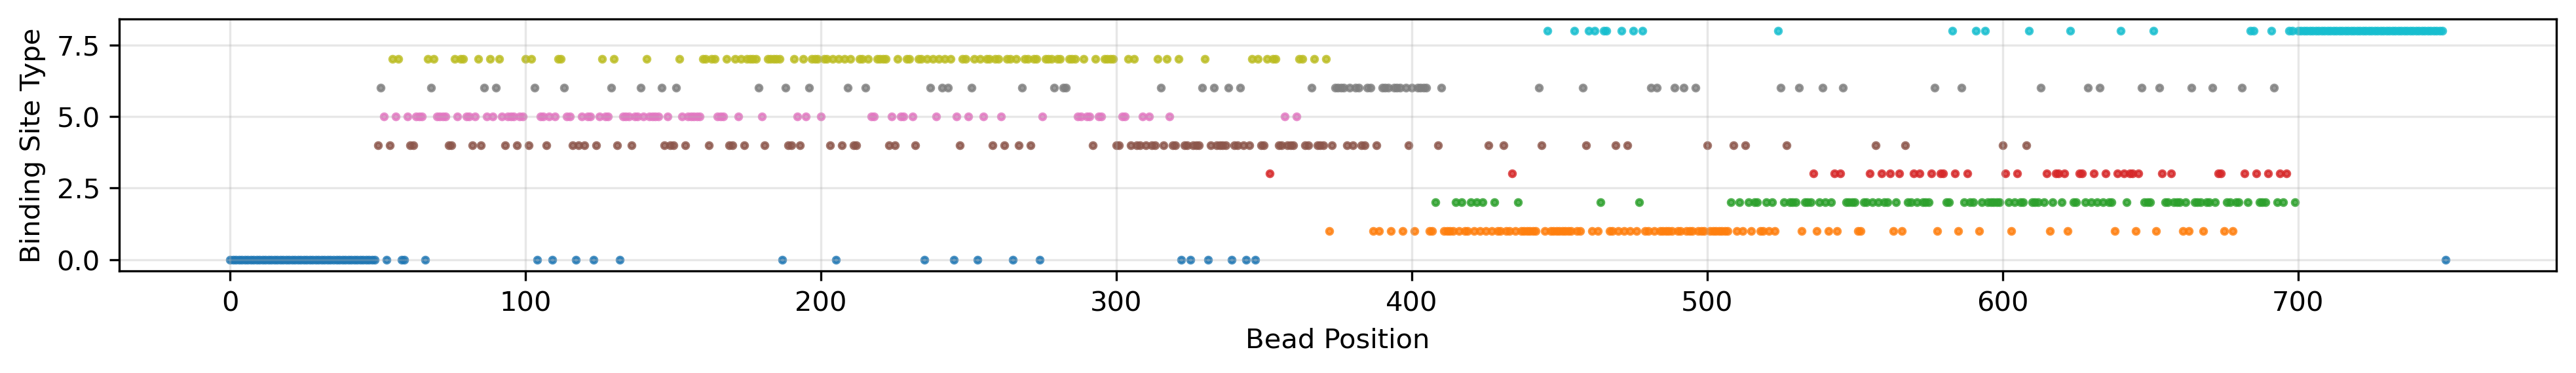

In [2]:
ns = 750
chain_interaction_binary = IMR90_data(ns, split_class_zero=True)

In [3]:
print(chain_interaction_binary.shape)

(9, 751)


In [3]:
chi_pp = 900*xp.ones((chain_interaction_binary.shape[0],chain_interaction_binary.shape[0]))
chi_ps = 950*xp.ones(chain_interaction_binary.shape[0])

N = 1000

nx = ny = 128
initial_qsr = xp.ones((nx, ny))
L = 56 #dimension of the box

width_gaussian = nx // 4
x = np.linspace(-1, 1, width_gaussian)
y = np.linspace(-1, 1, width_gaussian)
X, Y = np.meshgrid(x, y, indexing='ij')
gaussian = np.exp(-(X**2 + Y**2)/0.1)
boundary = np.zeros((nx,ny))
boundary[nx//2-width_gaussian//2:nx//2+width_gaussian//2,nx//2-width_gaussian//2:nx//2+width_gaussian//2] += gaussian

boundary = xp.random.rand(nx,ny)

polymer = Scft(
    N = N,
    Lx=L, Ly=L,
    phibar=0.1, # volume fraction of polymer
    l_p=xp.sqrt(N),
    n_seg=1, # contour length of polymer normalized from 0-1
    nx=nx, ny=ny,
    ns=ns,
    iterations=7000,
    error_tol=1e-12,
    chain_interaction=xp.asarray(chain_interaction_binary),
    self_avoiding=0,
    initial_qsr=xp.array(boundary),
    mixing_rate=0.004,
    chi_polymer_block = chi_pp,
    chi_polymer_s = chi_ps,
    PB = 1,
    close_boundary=True,
)

In [4]:
wsr, qsr_initial, qsr_d_initial, diff, free_energy_hist = initialization(polymer, seed = 5, shift = 0)

In [11]:
polymer.iterations = 3000
wsr, phi, phi_blocks, qsr, qsr_d, diff, free_energy_hist = scft_loop(polymer, wsr, qsr_initial, qsr_d_initial, diff, free_energy_hist)

100%|██████████| 3000/3000 [27:35<00:00,  1.81it/s] 


In [40]:
np.savez("chi_n_900_950.npz", wsr = wsr, phi = phi, phi_blocks = phi_blocks, qsr = qsr, qsr_d = qsr_d, diff = diff, free_energy_hist = free_energy_hist)

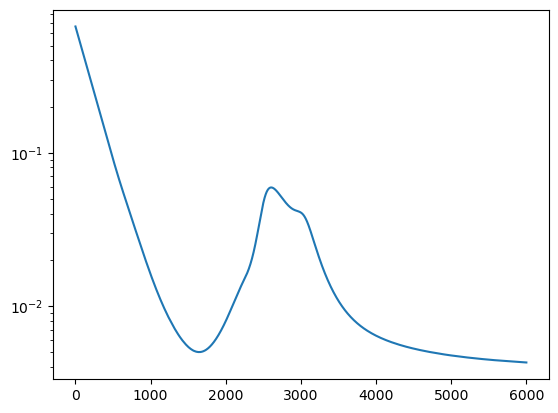

In [12]:
plt.plot(diff)
plt.yscale('log')

In [13]:
@njit(parallel=True)
def pair_correlation_2D_vectorized_numba(rho):
    """
    Numba-optimized version of your pair correlation function.
    """
    # 1) Normalize
    #    - Instead of keepdims=True, we'll expand the division manually
    #      using [:, None, None].
    ns_plus_1, nx, ny = rho.shape

    # ----------------------------------------------------------------------
    # 1) Normalize over each 2D slice: qsr[i, :, :] / mean(qsr[i, :, :])
    # ----------------------------------------------------------------------
    for i in prange(ns_plus_1):
        # Compute the mean of qsr[i] manually
        slice_sum = 0.0
        for x in range(nx):
            for y in range(ny):
                slice_sum += rho[i, x, y]
        slice_mean = slice_sum / (nx * ny)

        # Divide that slice by its mean
        for x in range(nx):
            for y in range(ny):
                rho[i, x, y] = rho[i, x, y] / slice_mean

    ns_plus_1 = rho.shape[0]
    nx = rho.shape[1]
    ny = rho.shape[2]

    correlation_function = np.zeros((ns_plus_1, ns_plus_1))

    # 2) Double loop over segment indices in parallel
    for i in prange(ns_plus_1):
        for k in prange(ns_plus_1):
            # Sum over x, y in one go:
            correlation_function[i, k] = np.sum(rho[i] * rho[k])

    # 3) Divide by (nx*ny)
    correlation_function /= (nx * ny)

    # 4) Subtract mean
    return correlation_function - np.mean(correlation_function)

In [14]:
corr_2d = pair_correlation_2D_vectorized_numba(to_numpy(qsr*qsr_d))

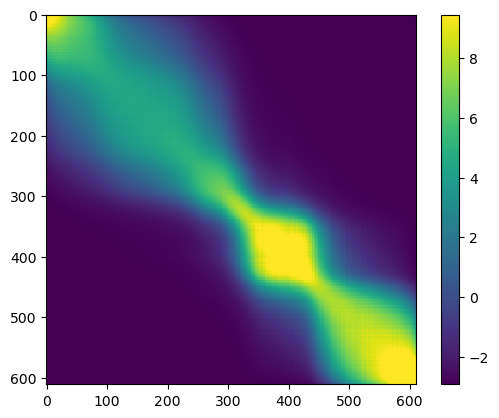

In [37]:
crop_range = 70
corr_2d_crop = corr_2d[crop_range:-crop_range, crop_range:-crop_range]
dynamic_range = 2.5 * np.std(corr_2d_crop)
plt.imshow(corr_2d_crop, cmap='viridis', interpolation='nearest', aspect=1,
           #vmin=-dynamic_range,
           vmax=+dynamic_range
           )

plt.colorbar()

In [38]:
def diagonal_decay_profile(A, agg="mean", normalize=True):
    """
    A: square matrix (N x N), ideally symmetric
    agg: "mean", "median", or a callable reducing 1D arrays -> scalar
    normalize: if True, divide by the k=0 value
    Returns:
        profile: length-N array, average intensity vs. distance k from diagonal
        horiz:   length-N array, average of super-diagonals  (offset +k)
        vert:    length-N array, average of sub-diagonals    (offset -k)
    """
    A = np.asarray(A)
    assert A.ndim == 2 and A.shape[0] == A.shape[1], "A must be square"
    N = A.shape[0]

    if agg == "mean":
        reducer = np.nanmean
    elif agg == "median":
        reducer = np.nanmedian
    elif callable(agg):
        reducer = agg
    else:
        raise ValueError("agg must be 'mean', 'median', or a callable")

    # horizontal: values k to the right of each diagonal element → super-diagonals
    horiz = np.array([reducer(np.diagonal(A, offset=k)) for k in range(N)])
    # vertical: values k below each diagonal element → sub-diagonals
    vert  = np.array([reducer(np.diagonal(A, offset=-k)) for k in range(N)])

    # Combine horizontal+vertical for each k (k=0 is just the main diagonal once)
    profile = horiz.copy()
    # For k>0, average super and sub diagonals together
    profile[1:] = 0.5 * (horiz[1:] + vert[1:])

    if normalize and profile[0] != 0:
        norm = profile / profile[0]
    else:
        norm = profile

    return norm, horiz, vert

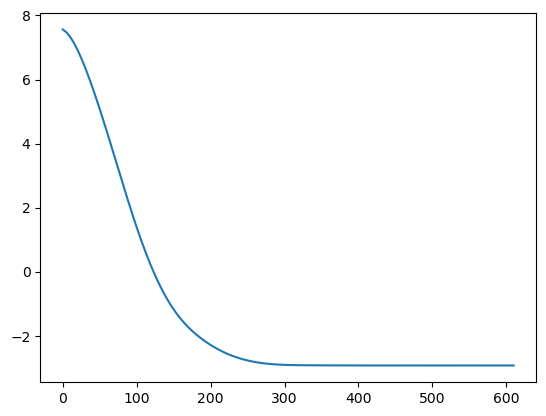

In [39]:
decay, horiz, vert = diagonal_decay_profile(corr_2d_crop, agg="mean", normalize=False)
plt.plot(decay, label = "Hi-C")

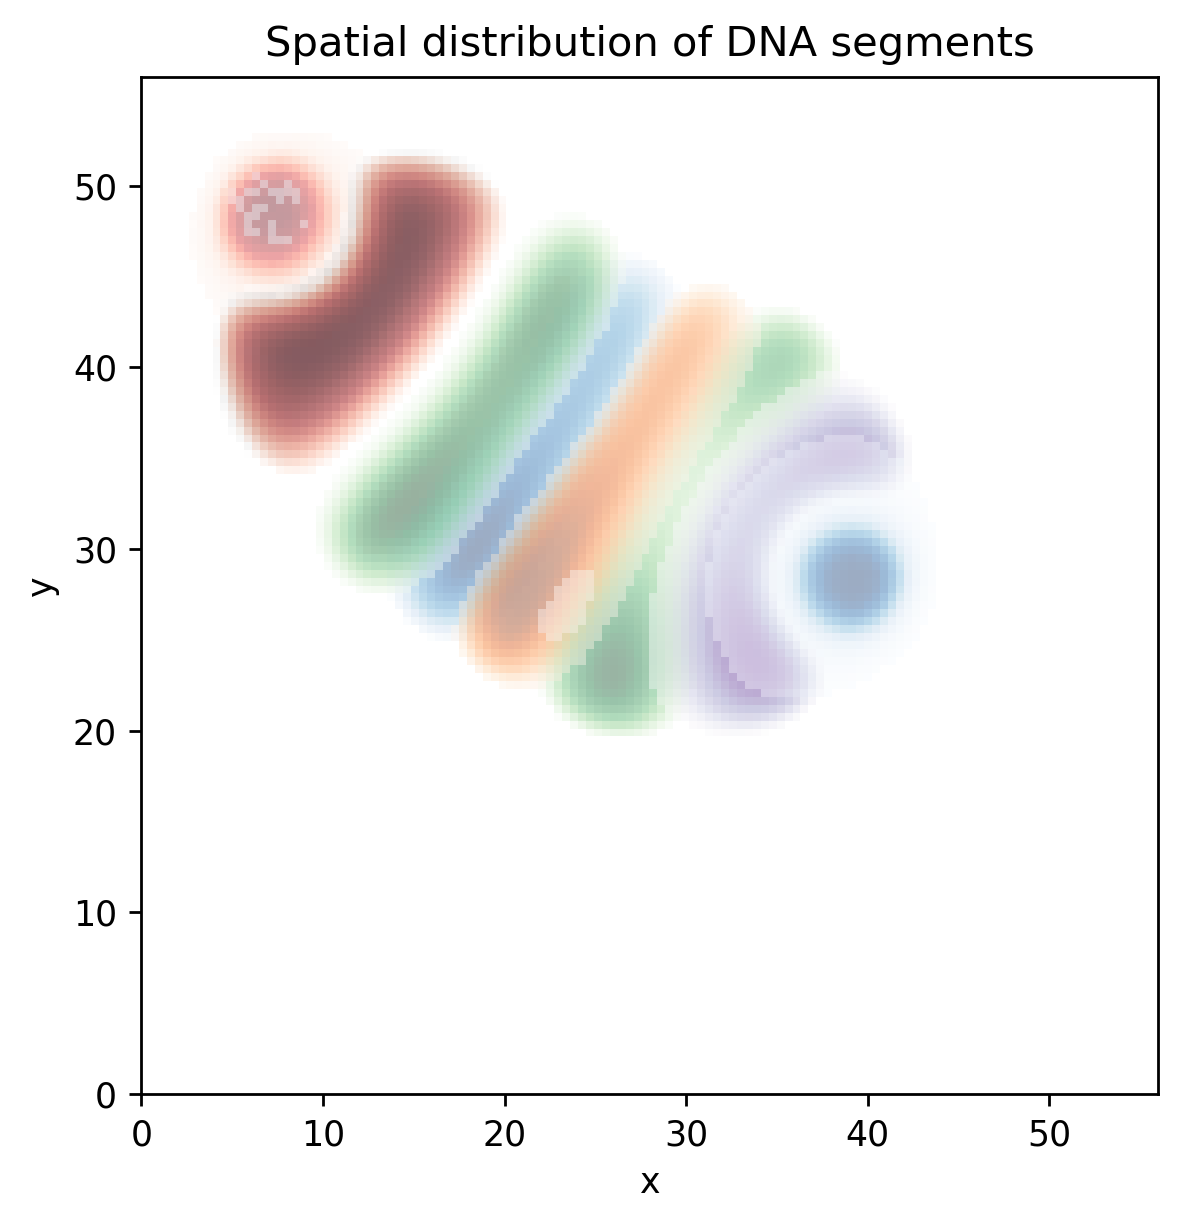

In [16]:
plot_phi_blocks_periodic(np.flip(to_numpy(phi_blocks), axis=0), extent=(0, polymer.Lx, 0, polymer.Ly), percentile=95, shift_x=0, shift_y=0)

76.02811180465042


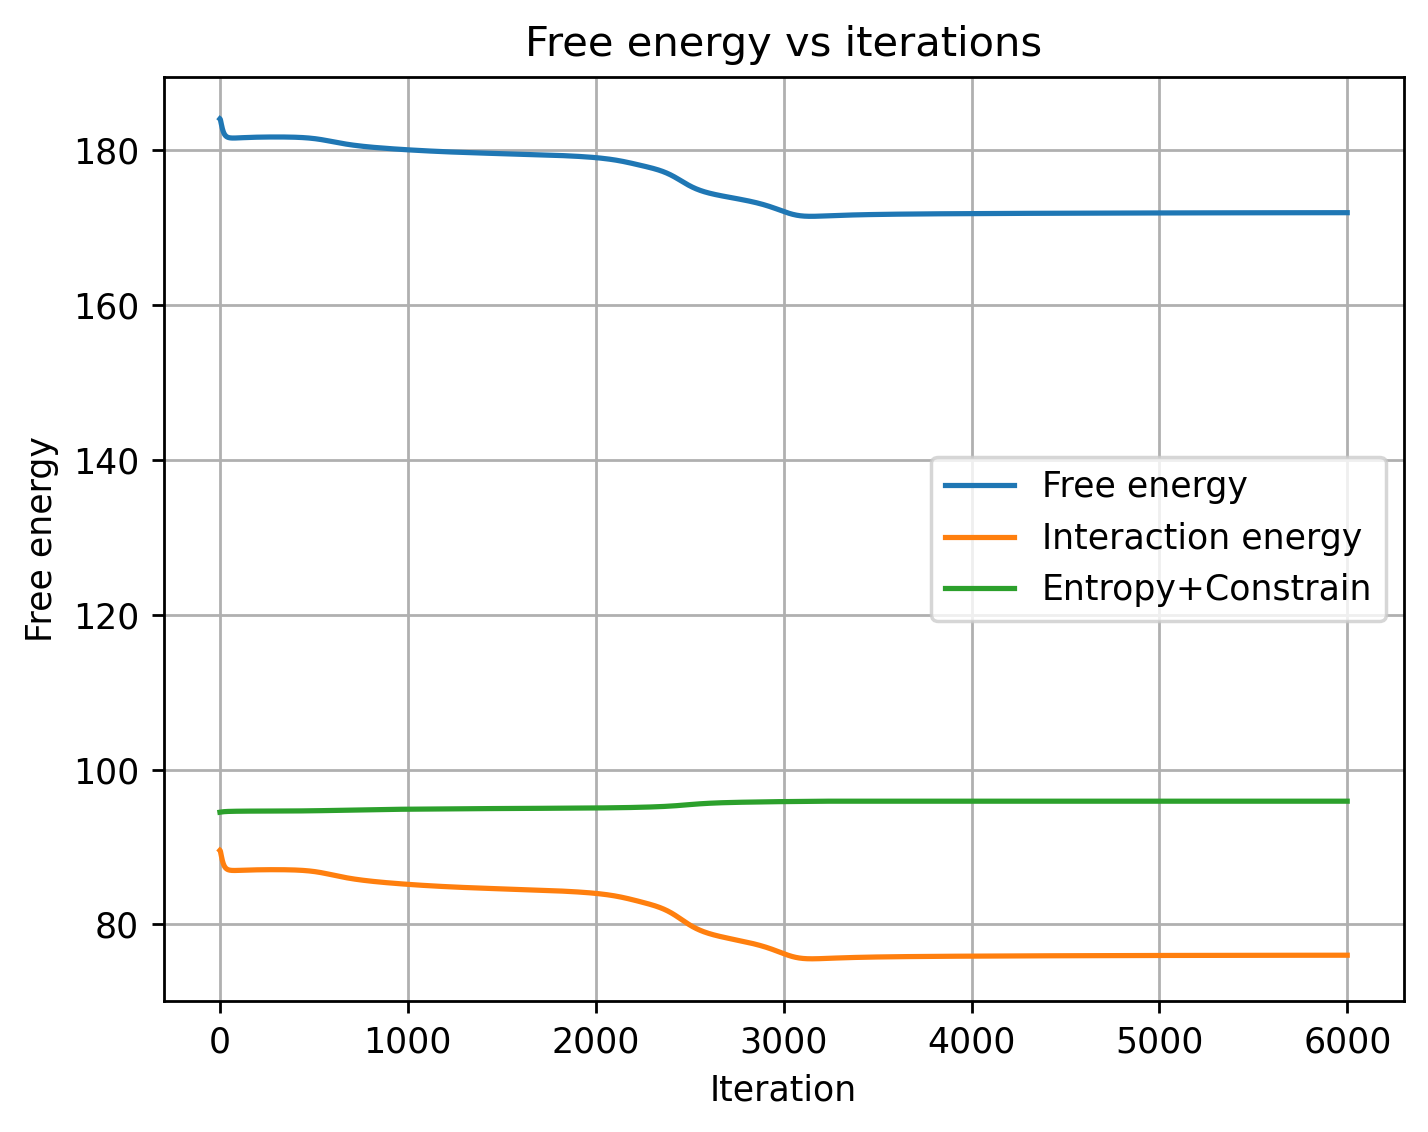

In [18]:
plt.figure(dpi=250)
free_energy_hist_plot = np.array(free_energy_hist)
plt.plot(free_energy_hist_plot[:, 0],label="Free energy")
plt.plot(free_energy_hist_plot[:, 1],label="Interaction energy")
plt.plot(free_energy_hist_plot[:, 2],label="Entropy+Constrain")
#plt.yscale('log')
plt.title("Free energy vs iterations")
plt.ylabel("Free energy")
plt.xlabel("Iteration")
plt.legend()
plt.grid()
print(free_energy_hist[-1][1])

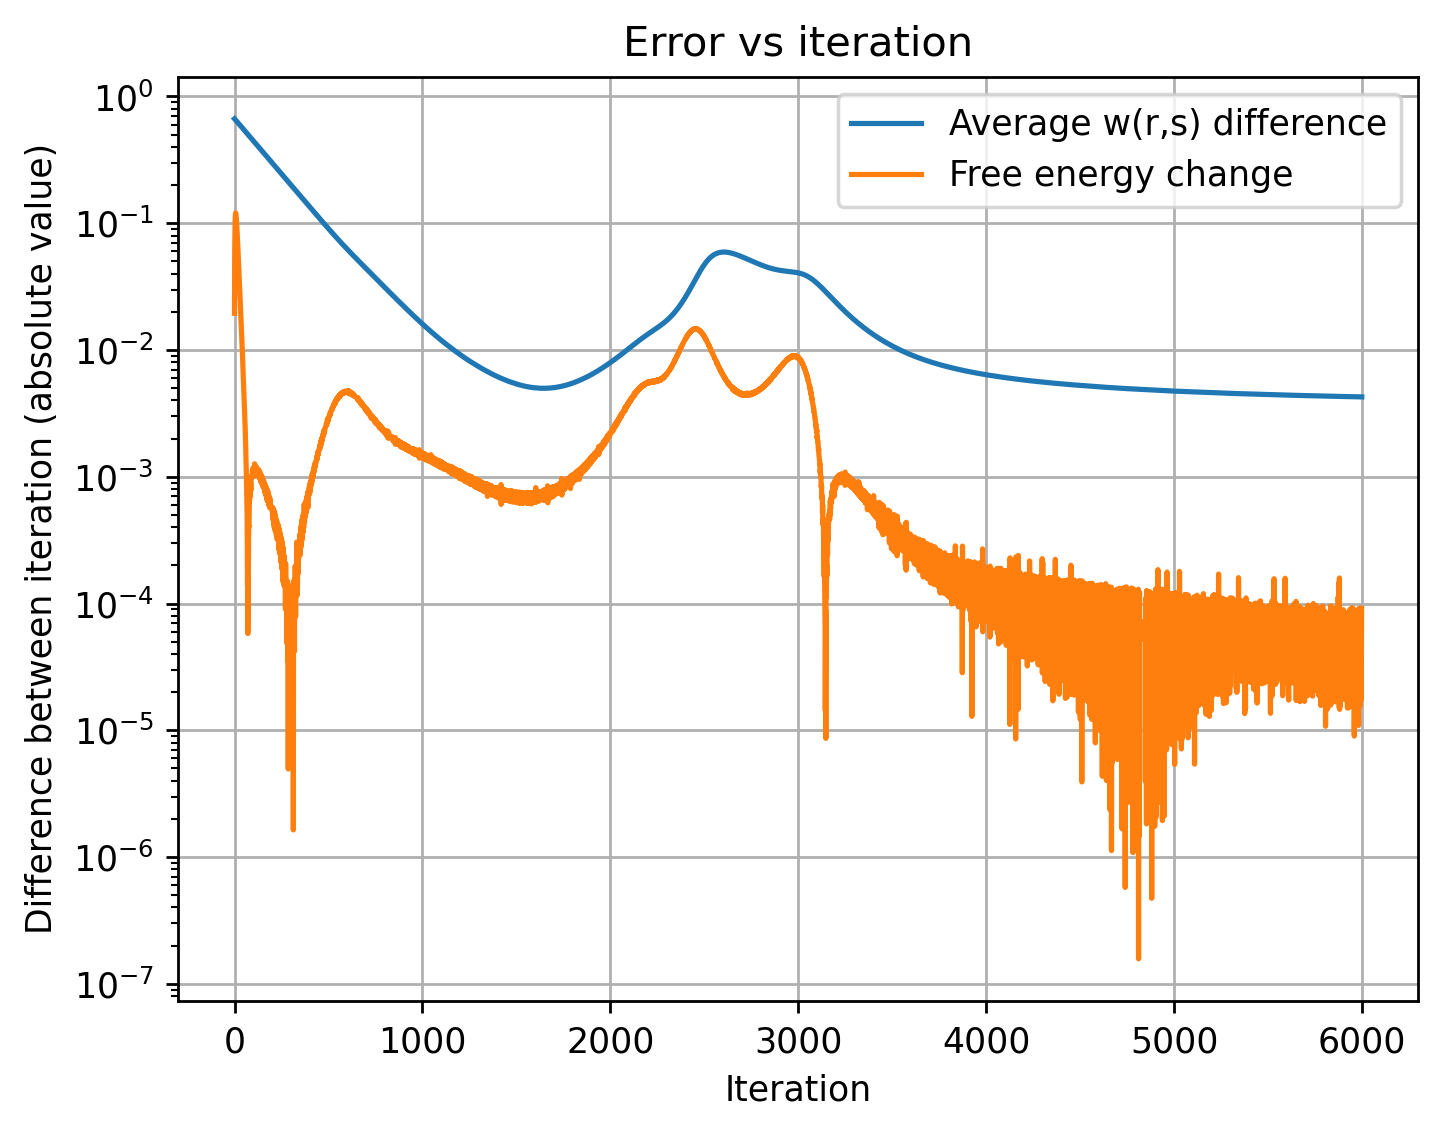

In [21]:
plt.figure(dpi=250)
plt.plot(diff, label="Average w(r,s) difference")
diff_energy = free_energy_hist_plot[1:, 0]-free_energy_hist_plot[:-1, 0]
plt.plot(abs(diff_energy), label="Free energy change")
plt.yscale('log')
#plt.title("Average difference in w(r,s) per iteration")
plt.title("Error vs iteration")
plt.ylabel("Difference between iteration (absolute value)")
plt.xlabel("Iteration")
plt.grid()
plt.legend()

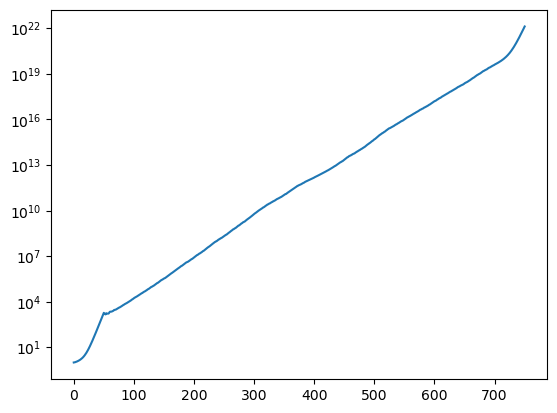

In [20]:
qsr_decay = np.mean(qsr, axis = (1,2))
plt.plot(to_numpy(qsr_decay))
plt.yscale('log')

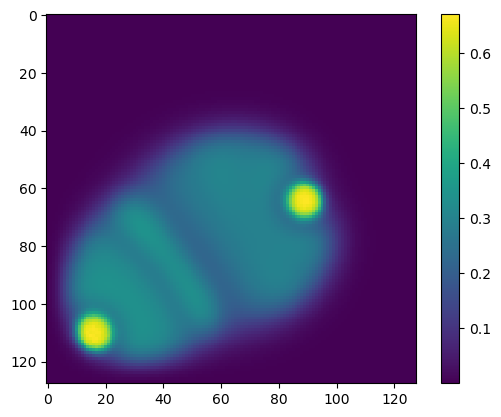

In [19]:
plt.imshow(to_numpy(phi), cmap='viridis', interpolation='nearest', aspect=1)
plt.colorbar()